# Twin data analysis
## Tables of contents
1. Load data
2. Change the dataframe formats (wide <-> long) for convenience 
3. Calculate interclass corelations between twin
4. Plot the icc values for each visual area

## Paths

In [1]:
import os
from pathlib import Path
cache_path       = Path('/data/crcns2021/hcpannot-cache')
image_cache_path = cache_path / 'annot-images'
v123_cache_path  = cache_path / 'annot-v123'
csulc_cache_path = cache_path / 'annot-csulc'
# The save path of the data branch:
data_path = Path('/data/crcns2021/results/data_branch/save')
# The processing path and subpaths:
proc_path    = Path('/data/crcns2021/results/proc')
traces_path  = proc_path / 'traces'
paths_path   = proc_path / 'paths'
means_path   = proc_path / 'means'
labels_path  = proc_path / 'labels'
reports_path = proc_path / 'reports'
fig_dir      = proc_path / 'figures'

# The file of visual surface areas for the ventral data.
ventral_sarea_path = proc_path / 'ventral_sareas.tsv'

# The hcpannot library path; if hcpannot is not on the path for
# this notebook, the notebook will try to figure out where it is
# and will use this directory as a backup.
hcpannot_lib_path = Path('~/code/hcp-annot-vc_analysis')

# If you aren't using /data
os.environ['HCPANNOT_LOAD_PATH'] = os.fspath(cache_path)

## Dependencies

In [2]:
# import necessary packages
import sys
sys.path.append('../src/')
import hcpannot
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st 
import neuropythy as ny
import matplotlib as mpl
import itertools
import warnings
import pingouin as pg
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from itertools import product
sys.path.append('../src/hcpannot/')
from visualization import plot_annot_properties as vis
from visualization import twin_analysis as tw
from hcpannot.config import subject_list, ventral_raters, dorsal_raters, region_areas
from hcpannot.io import load_allreports

# Note the cache path we want to use outside the docker container;
# normally this gets set by the Docker startup, so here outside
# the docker container we set it manually.
hcpannot.interface.default_load_path = str(cache_path)

# The subject IDs we are processing over, as a numpy array.
sids = np.array(subject_list)
hemis = ['lh', 'rh']

warnings.simplefilter(action='ignore', category=FutureWarning)

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Font settings
This block will be gone before we finalize the clean ups

In [92]:
# Additional matplotlib preferences:
font_data = {'family':'sans-serif',
             'sans-serif':['HelveticaNeue'],
             'size': 12,
             'weight': 'light'}
mpl.rc('font',**font_data)
# we want relatively high-res images, especially when saving to disk.
mpl.rcParams['figure.dpi'] = 72*3
mpl.rcParams['savefig.dpi'] = 72*4
mpl.rcParams['axes.unicode_minus'] = False

rc = {'text.color': 'black',
      'axes.labelcolor': 'black',
      'axes.labelweight': 'light',
      'axes.linewidth':     1,
      'xtick.major.width':    1,
      'ytick.major.width':    1,
      'xtick.color': 'black',
      'ytick.color': 'black',
      'xtick.labelcolor': 'black',
      'ytick.labelcolor': 'black',
      'font.family': 'helveticaneue',
      'font.weight': 'light',
      'font.size' : 10,
      'figure.dpi': 72*3,
      'savefig.dpi': 72*4,
      }
mpl.rcParams.update(rc)

In [4]:
roi_list = ['V1', 'V2', 'V3', 'hV4', 'VO','VO1', 'VO2']


# 1. Loading Early Visual Areas (V1, V2, V3)

The early visual area data (V1, V2, V3) are pre-saved in wide format (seperately for each hemisphere) using the `neuropythy` function. Since both wide and long formats are needed for plotting, we will also convert the data from wide to long format for these regions.

In [5]:
#early df is already in wide frame 
wide_early_df = ny.data['hcp_lines'].surface_area_dataframe
cols = ['sid','anatomist','roiLV1','roiLV2','roiLV3','roiRV1','roiRV2','roiRV3']
new_cols = ['sid','researcher','lh_V1_mm2','lh_V2_mm2','lh_V3_mm2','rh_V1_mm2','rh_V2_mm2','rh_V3_mm2']
wide_early_df = wide_early_df[cols]
wide_early_df = wide_early_df.rename(columns=dict(zip(cols, new_cols)))

wide_early_df.head()

,sid,researcher,lh_V1_mm2,lh_V2_mm2,lh_V3_mm2,rh_V1_mm2,rh_V2_mm2,rh_V3_mm2
0,100610,A1,2265.887920,1780.173294,1143.821972,1913.956563,1466.693863,1465.402690
1,100610,A2,2240.237938,1661.168048,1227.444715,1875.902653,1746.667678,1124.642891
2,100610,A3,2174.752668,1566.739454,1085.699232,1887.691812,1573.167764,1119.448009
3,100610,A4,2105.550586,1889.817786,1066.602000,1788.785728,1861.135949,1117.008663
4,100610,mean,2182.648869,1728.088569,1119.816370,1860.693153,1659.008599,1172.995850


### Convert `wide_early_df` to long format `early_df`
We also need to shape this dataframe into a long format, in order to use it for inter-correlation. To do so we merge left and right hemisphere into one column.

In [6]:
long_early_df = pd.DataFrame({})
for hemi in ['lh', 'rh']:
    tmp_cols = [col for col in wide_early_df.columns if hemi in col]
    tmp_new_cols = [col.replace(f'{hemi}_', '') for col in tmp_cols]
    tmp = wide_early_df[['sid', 'researcher'] + tmp_cols]
    tmp = tmp.rename(columns=dict(zip(tmp_cols, tmp_new_cols)))
    tmp['hemisphere'] = hemi
    long_early_df = pd.concat((long_early_df, tmp))
    
long_early_df.head()

,sid,researcher,V1_mm2,V2_mm2,V3_mm2,hemisphere
0,100610,A1,2265.887920,1780.173294,1143.821972,lh
1,100610,A2,2240.237938,1661.168048,1227.444715,lh
2,100610,A3,2174.752668,1566.739454,1085.699232,lh
3,100610,A4,2105.550586,1889.817786,1066.602000,lh
4,100610,mean,2182.648869,1728.088569,1119.816370,lh


## Loading Ventral Visual Area Data (hV4, VO1, VO2)

Next, we load the data for the ventral visual areas (hV4, VO1, VO2). These are newly added datasets specific to this project. Using the `load_allreports()` function, we load pre-processed surface size data for the ventral regions from the `reports_path`. Unlike the early visual area data, these are already stored in long format, so this time we need to convert them to a wide format later.

Additionally, we want to analyze a combined region ('VO'), which is a sum of the VO1 and VO2 areas. Given the relatively small size of these individual regions, the combined ROI may provide more stable results.

In [7]:
long_ventral_df = load_allreports('ventral', sids=sids, reports_path=reports_path)
long_ventral_df = long_ventral_df.rename(columns = {'rater': 'researcher'})
# Adding VO (VO1+VO2)
long_ventral_df['VO_mm2'] = long_ventral_df[['VO1_mm2', 'VO2_mm2']].sum(axis = 1, skipna = True)
long_ventral_df['VO_percent'] = long_ventral_df[['VO1_percent', 'VO2_percent']].sum(axis = 1, skipna = True)
long_ventral_df.head()

,researcher,sid,hemisphere,hV4_mm2,hV4_percent,VO1_mm2,VO1_percent,VO2_mm2,VO2_percent,cortex_mm2,VO_mm2,VO_percent
0,R1,100610,lh,803.427917,0.776482,242.537170,0.234403,313.341797,0.302833,103470.296875,555.878967,0.537235
1,R1,100610,rh,672.364075,0.647234,123.659592,0.119038,372.956116,0.359017,103882.664062,496.615707,0.478054
2,R1,102311,lh,607.411804,0.628980,191.655533,0.198461,342.115021,0.354263,96570.992188,533.770554,0.552723
3,R1,102311,rh,844.784912,0.869254,437.872620,0.450556,287.723694,0.296058,97185.007812,725.596313,0.746613
4,R1,102816,lh,986.771118,1.115701,402.001831,0.454527,218.018784,0.246505,88444.023438,620.020615,0.701032


# 2. Convert format 
## `ventral_df` into wide format `wide_ventral_df` 

In [8]:
wide_ventral_df = {}
ventral_df_areas = ['hV4', 'VO1', 'VO2', 'VO']

for hemi in ['lh','rh']:
    tmp_cols = [f'{col}_mm2' for col in ventral_df_areas+['cortex']]
    tmp_cols += [f'{col}_percent' for col in ventral_df_areas]
    tmp_new_cols = [f'{hemi}_{col}' for col in tmp_cols]
    
    tmp = long_ventral_df.query('hemisphere == @hemi')
    tmp = tmp.rename(columns=dict(zip(tmp_cols, tmp_new_cols)))
    wide_ventral_df[hemi] = tmp.drop(columns=['hemisphere'])

wide_ventral_df = pd.merge(wide_ventral_df['lh'], wide_ventral_df['rh'], 
                           on=['researcher','sid'])
wide_ventral_df.head()

,researcher,sid,lh_hV4_mm2,lh_hV4_percent,lh_VO1_mm2,lh_VO1_percent,lh_VO2_mm2,lh_VO2_percent,lh_cortex_mm2,lh_VO_mm2,lh_VO_percent,rh_hV4_mm2,rh_hV4_percent,rh_VO1_mm2,rh_VO1_percent,rh_VO2_mm2,rh_VO2_percent,rh_cortex_mm2,rh_VO_mm2,rh_VO_percent
0,R1,100610,803.427917,0.776482,242.537170,0.234403,313.341797,0.302833,103470.296875,555.878967,0.537235,672.364075,0.647234,123.659592,0.119038,372.956116,0.359017,103882.664062,496.615707,0.478054
1,R1,102311,607.411804,0.628980,191.655533,0.198461,342.115021,0.354263,96570.992188,533.770554,0.552723,844.784912,0.869254,437.872620,0.450556,287.723694,0.296058,97185.007812,725.596313,0.746613
2,R1,102816,986.771118,1.115701,402.001831,0.454527,218.018784,0.246505,88444.023438,620.020615,0.701032,681.384521,0.765621,368.956482,0.414569,304.647095,0.342309,88997.625000,673.603577,0.756878
3,R1,104416,425.192108,0.446362,308.952637,0.324335,282.064209,0.296108,95257.218750,591.016846,0.620443,531.435059,0.558219,275.978821,0.289888,278.540619,0.292579,95201.968750,554.519440,0.582466
4,R1,105923,1050.326660,1.036963,206.238022,0.203614,265.284821,0.261910,101288.734375,471.522842,0.465523,746.769409,0.737907,286.591187,0.283190,310.087646,0.306408,101201.000000,596.678833,0.589598


## Merge `wide_early_df` and `wide_ventral_df` (output: `wide_visual_df`)

In [9]:
wide_visual_df = pd.merge(wide_early_df, wide_ventral_df, on=['sid','researcher'])
# wide_early_df does not have percent columns 
for hemi, roi in product(['lh','rh'], region_areas['early']):
    wide_visual_df[f'{hemi}_{roi}_percent'] = (wide_visual_df[f'{hemi}_{roi}_mm2'] / wide_visual_df[f'{hemi}_cortex_mm2'])*100

## Merge `long_early_df` and `long_ventral_df` (output: `long_visual_df`)

In [10]:
long_visual_df = pd.merge(long_early_df, long_ventral_df, on=['sid','researcher', 'hemisphere'])
# early_df does not have percent columns 
for roi in region_areas['early']:
    long_visual_df[f'{roi}_percent'] = (long_visual_df[f'{roi}_mm2'] / long_visual_df[f'cortex_mm2'])*100

# 2. ICC calculation 

In [11]:
ds = ny.data['hcp_lines']
wide_twin_df = pd.DataFrame({'twin_type':[], 'sid1':[], 'sid2':[]})
twin_types = [k for k in ds.retinotopy_sibling_pairs.keys() if not k=='nontwin_siblings']
for k in twin_types:
    twin_ids = ds.retinotopy_sibling_pairs[k]
    tmp = pd.DataFrame({'twin_type':[], 'sid1':[], 'sid2':[]})
    if twin_ids.ndim != 2:
        twin_ids = twins_ids.reshape(1,-1) 
    tmp['sid1'] = twin_ids[:,0]
    tmp['sid2'] = twin_ids[:,1]
    tmp['twin_type'] = k
    wide_twin_df = pd.concat((wide_twin_df, tmp), ignore_index=True)
    
wide_twin_df = wide_twin_df.reset_index().rename(columns={'index':'twin_index'})
wide_twin_df['twin_index'] = wide_twin_df['twin_index'].astype(int)
long_twin_df = pd.melt(wide_twin_df, id_vars=['twin_type', 'twin_index'], 
                       value_vars=['sid1','sid2'], 
                       var_name='sid_type', value_name='sid')
long_twin_df['sid'] = long_twin_df['sid'].astype(int)

# Twin surface area dataframe for calculating icc

For one case (one twin type, all twins, one hemisphere, one roi), it takes about 50.4 ms. 

```
%%time
pg.intraclass_corr(data=tmp, 
                   targets='twin_index', 
                   raters='sid_type', 
                   ratings=f'{hemi}_{roi}_percent', 
                   nan_policy='omit').query('Type == "ICC1"')
```


## icc for all cases

In [14]:
twin_types

['dizygotic_twins', 'unrelated_pairs', 'monozygotic_twins']

In [77]:
# icc type 2 
twin_types = [k for k in ds.retinotopy_sibling_pairs.keys() if not k=='nontwin_siblings']
icc_type =2 #ICC type
n_twins = wide_twin_df.query('twin_type != "unrelated_pairs"')['twin_index'].count()
icc_type_list = [1,2]
all_twin_icc_df = pd.DataFrame({})
for icc_type in icc_type_list:
    twin_icc_df = pd.DataFrame({})
    for tw_type in twin_types[:]:
        save_path = os.path.join(proc_path, 'twins', f'icc-{icc_type}_hemi-sum_twtype-{tw_type}_roi-all.h5')
        result = tw.calculate_icc_for_all(long_twin_df, 
                                          wide_visual_df, 
                                          [tw_type], 
                                          ['sum'], 
                                          roi_list, 
                                          icc_type=icc_type, 
                                          save_path=save_path)
        twin_icc_df = pd.concat((twin_icc_df, result), ignore_index=True)
    all_twin_icc_df = pd.concat((all_twin_icc_df, twin_icc_df), ignore_index=True)

/data/crcns2021/results/proc/twins/icc-1_hemi-sum_twtype-monozygotic_twins_roi-all.h5 doesnt exist. calculating now...


7it [00:00, 28.55it/s]


/data/crcns2021/results/proc/twins/icc-1_hemi-sum_twtype-monozygotic_twins_roi-all.h5 saved
/data/crcns2021/results/proc/twins/icc-1_hemi-sum_twtype-dizygotic_twins_roi-all.h5 doesnt exist. calculating now...


7it [00:00, 32.37it/s]


/data/crcns2021/results/proc/twins/icc-1_hemi-sum_twtype-dizygotic_twins_roi-all.h5 saved
/data/crcns2021/results/proc/twins/icc-1_hemi-sum_twtype-unrelated_pairs_roi-all.h5 doesnt exist. calculating now...


7it [01:58, 16.87s/it]

/data/crcns2021/results/proc/twins/icc-1_hemi-sum_twtype-unrelated_pairs_roi-all.h5 saved


In [82]:
all_twin_icc_df = all_twin_icc_df.replace(np.nan, "ICC2")
all_twin_icc_df

,Type,ICC,F,df1,df2,pval,CI95%,hemi,ROI,twin_type
0,ICC1,0.858547,13.138945,37,38,7.893895e-13,"[0.75, 0.92]",sum,V1,monozygotic_twins
1,ICC1,0.882967,16.089240,37,38,2.705143e-14,"[0.79, 0.94]",sum,V2,monozygotic_twins
2,ICC1,0.793756,8.697239,37,38,5.516176e-10,"[0.64, 0.89]",sum,V3,monozygotic_twins
3,ICC1,0.471096,2.781404,49,50,2.210998e-04,"[0.23, 0.66]",sum,hV4,monozygotic_twins
4,ICC1,0.351183,2.082533,49,50,5.484542e-03,"[0.09, 0.57]",sum,VO,monozygotic_twins
5,ICC1,0.415692,2.422854,49,50,1.127671e-03,"[0.16, 0.62]",sum,VO1,monozygotic_twins
6,ICC1,0.261703,1.708938,49,50,3.094149e-02,"[-0.01, 0.5]",sum,VO2,monozygotic_twins
7,ICC1,0.692188,5.497476,32,33,2.223268e-06,"[0.46, 0.83]",sum,V1,dizygotic_twins
8,ICC1,0.756010,7.197057,32,33,8.284360e-08,"[0.56, 0.87]",sum,V2,dizygotic_twins
9,ICC1,0.492221,2.938719,32,33,1.397008e-03,"[0.19, 0.71]",sum,V3,dizygotic_twins


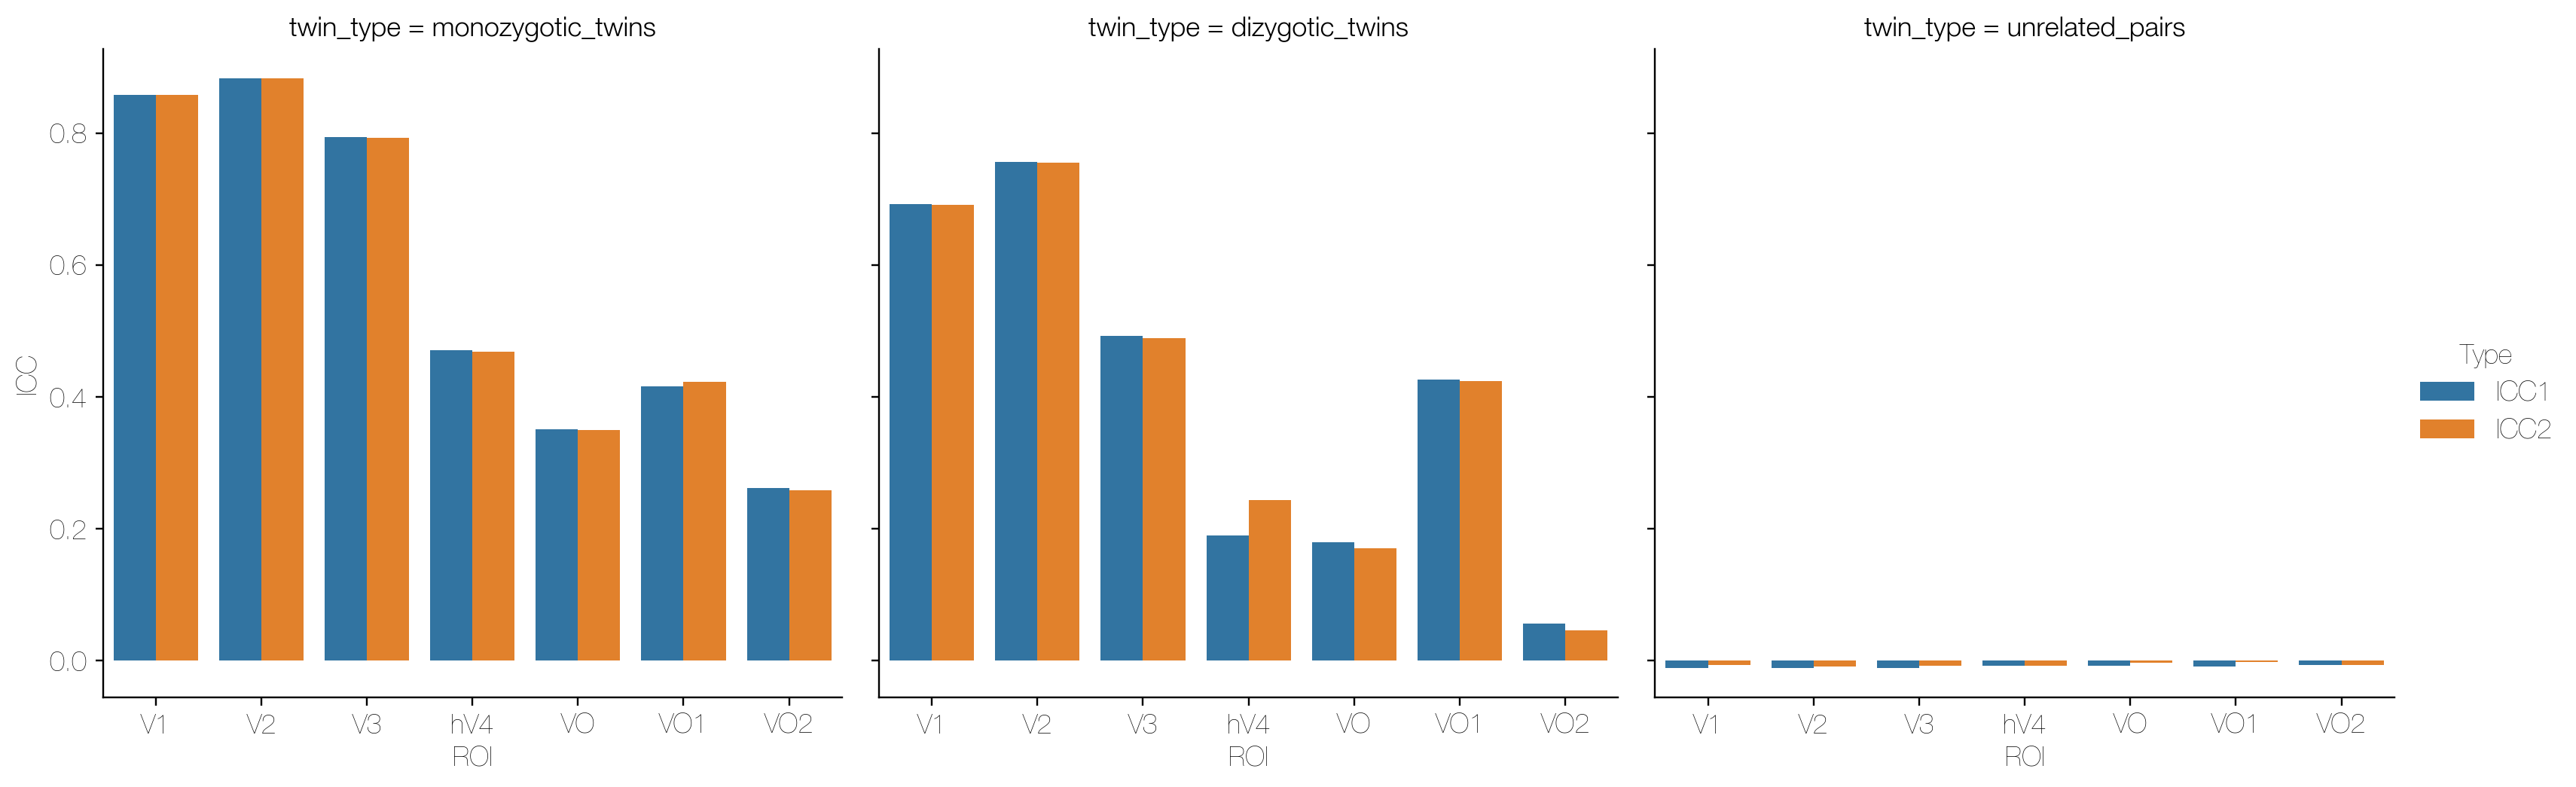

In [83]:
sns.catplot(all_twin_icc_df, x='ROI', y='ICC', hue='Type', kind='bar', col='twin_type')

In [84]:
# icc type 2 
twin_types = [k for k in ds.retinotopy_sibling_pairs.keys() if not k=='nontwin_siblings']
icc_type =2 #ICC type
n_twins = wide_twin_df.query('twin_type != "unrelated_pairs"')['twin_index'].count()
twin_icc_df = pd.DataFrame({})
for tw_type in twin_types[:]:
    save_path = os.path.join(proc_path, 'twins', f'icc-{icc_type}_hemi-sum_twtype-{tw_type}_roi-all.h5')
    result = tw.calculate_icc_for_all(long_twin_df, 
                                      wide_visual_df, 
                                      [tw_type], 
                                      ['sum'], 
                                      roi_list, 
                                      icc_type=icc_type, 
                                      save_path=save_path)
    twin_icc_df = pd.concat((twin_icc_df, result), ignore_index=True)


In [85]:
mono_df = twin_icc_df.query('twin_type == "monozygotic_twins"')[['hemi','ROI','ICC']]
dizy_df = twin_icc_df.query('twin_type == "dizygotic_twins"')[['hemi','ROI','ICC']]
h2_df = pd.merge(mono_df, dizy_df, on=['hemi','ROI'])
h2_df['h2'] = 2*(h2_df['ICC_x'] - h2_df['ICC_y'])
h2_df = h2_df.rename(columns={'ICC_x':'mono_ICC', 'ICC_y':'dizy_ICC'})

# For bootstraps

In [86]:
n_bootstraps=10000
bts_icc_df = pd.DataFrame({})
for roi in roi_list:
    save_path = os.path.join(proc_path, 'twins', f'bootstraps-{n_bootstraps}_icc-{icc_type}_hemi-sum_twtype-all_roi-{roi}.h5')
    tmp = tw.bootstrap_calculate_icc_for_all(long_twin_df, wide_visual_df, 
                                             n_samples=n_twins, 
                                             n_bootstraps=n_bootstraps, 
                                             hemi='sum', roi=roi,
                                             icc_type=icc_type,
                                             save_path=save_path)
    bts_icc_df = pd.concat((bts_icc_df, tmp), ignore_index=True)

# Fig 4b. Heriability ICC plot
## seperately for each hemisphere, and use CI values as error bars

In [172]:
bts_icc_df.query('ROI == "VO1" & hemi == "sum"')

,bootstrap,ROI,hemi,mono_ICC,dizy_ICC,h2
50000,0,VO1,sum,0.459824,0.429443,0.060762
50001,1,VO1,sum,0.280885,0.290227,-0.018684
50002,2,VO1,sum,0.369261,0.340762,0.056998
50003,3,VO1,sum,0.278829,0.323439,-0.089221
50004,4,VO1,sum,0.438902,0.341814,0.194175
...,...,...,...,...,...,...
59995,9995,VO1,sum,0.446263,0.307419,0.277688
59996,9996,VO1,sum,0.509104,0.347319,0.323570
59997,9997,VO1,sum,0.334103,0.486507,-0.304807
59998,9998,VO1,sum,0.249136,0.454555,-0.410839


In [87]:
bts_icc_ci_df = pd.DataFrame({'ROI' :['V1','V2','V3','hV4','VO1','VO2','VO'], 'hemi':['sum']*7})
for col in ['mono_ICC', 'dizy_ICC', 'h2']:
    tmp = tw.calculate_confidential_interval(bts_icc_df, col, to_group=['ROI', 'hemi'])
    #col_list = [f'{col}_ci_68', f'{col}_ci_95']
    bts_icc_ci_df = pd.merge(bts_icc_ci_df, tmp, on=['ROI','hemi'])

In [88]:
final_icc_2_df = pd.merge(h2_df, bts_icc_ci_df, on=['ROI','hemi'])

In [89]:
final_icc_2_df

,hemi,ROI,mono_ICC,dizy_ICC,h2,mono_ICC_ci_68,mono_ICC_ci_95,dizy_ICC_ci_68,dizy_ICC_ci_95,h2_ci_68,h2_ci_95
0,sum,V1,0.858281,0.691360,0.333842,"[0.8148169232167677, 0.8883127771976305]","[0.7634262537363788, 0.911989860791326]","[0.5695115538114811, 0.7812642124960009]","[0.4298768191579408, 0.8383397506661009]","[0.1276155223077189, 0.5823281028814866]","[-0.020173993711265176, 0.8553533550689038]"
1,sum,V2,0.882848,0.755608,0.254481,"[0.8444741972594647, 0.9096268345273315]","[0.7995138557240228, 0.9320957050649932]","[0.6326068221902696, 0.8264414557849143]","[0.4844692173566081, 0.8776549259690325]","[0.09184992813005342, 0.4967386698532569]","[-0.03954566177421963, 0.798626276402409]"
2,sum,V3,0.793268,0.489422,0.607692,"[0.7277561686642963, 0.8351044165621968]","[0.6547440707051064, 0.8722229987258951]","[0.3050427839534959, 0.6134768096196869]","[0.13637164950985992, 0.7263771497216296]","[0.31207924963196626, 0.9732512795357574]","[0.05629865607355596, 1.3210331582213426]"
3,sum,hV4,0.468229,0.243596,0.449265,"[0.3735909055997559, 0.5423775744380899]","[0.271763700120497, 0.6095285401471092]","[0.11730696911437441, 0.36637559480836007]","[-0.007355549643774112, 0.48641113594588326]","[0.13426135028718594, 0.7325345852442401]","[-0.17385534939421662, 1.0325141816031718]"
4,sum,VO,0.349565,0.170025,0.359081,"[0.19960680568273106, 0.4697764619454443]","[0.04598226887671644, 0.5807332079572065]","[-0.0502039692722165, 0.3444077140739116]","[-0.25985201442708533, 0.49492461412596406]","[-0.10824461830346123, 0.8485220047137472]","[-0.5216584191226652, 1.3381712312544853]"
5,sum,VO1,0.422764,0.424354,-0.003180,"[0.2954085358026604, 0.528590013721036]","[0.1695186125158086, 0.6243735597163192]","[0.20030864394454467, 0.5682473746847796]","[-0.007121114993190454, 0.6606731050638077]","[-0.37722442500687486, 0.4837692561642639]","[-0.7034087621581915, 0.9391757986395114]"
6,sum,VO2,0.258537,0.046415,0.424244,"[0.08698929704074293, 0.4040019362984125]","[-0.07561986932195966, 0.5286038702539594]","[-0.10923232089288094, 0.19459735270572184]","[-0.25491093034461565, 0.3331517539763212]","[-0.03335306855070505, 0.8367156402122135]","[-0.4701544101489337, 1.2492540763237816]"


In [90]:
categories = twin_icc_df['ROI'].unique()
hues = twin_icc_df['twin_type'].unique()
category_positions = np.arange(len(categories))  # Base positions for categories
color_map = dict(zip(['mono_ICC','dizy_ICC','unrelated_pairs'],  ['red','cyan','grey'])) # Create a dictionary to map hues to colors
labels = dict(zip(['mono_ICC','dizy_ICC','unrelated_pairs'], ['Monozygotic','Dizygotic','Unrelated']))

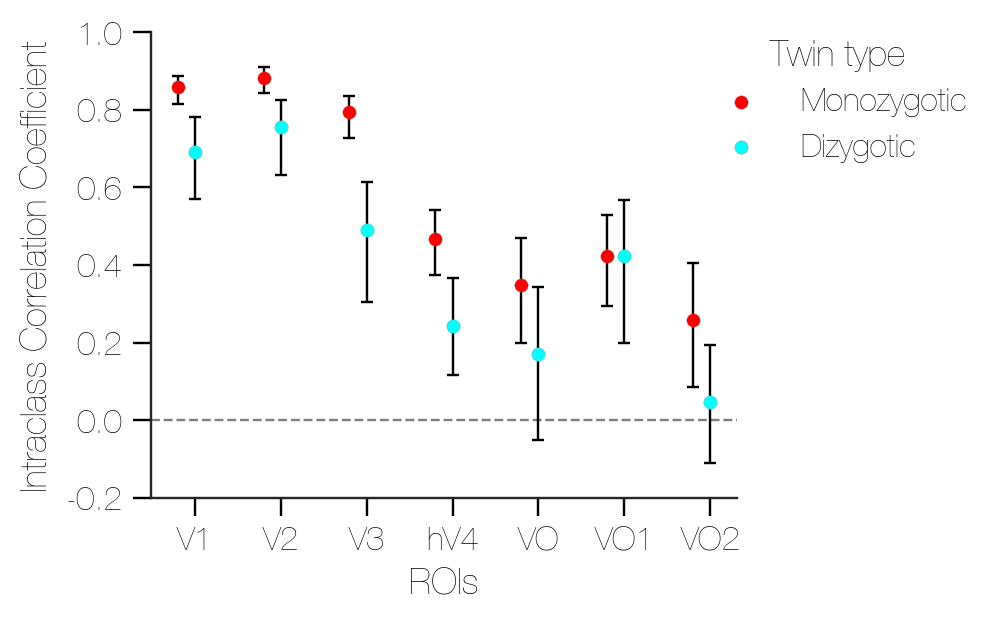

In [123]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3.5,2.8))

rc = {'text.color': 'black',
      'axes.labelcolor': 'black',
      'axes.labelweight': 'light',
      'axes.linewidth':     0.8,
      'xtick.major.width':    0.8,
      'ytick.major.width':    0.8,
      'xtick.color': 'black',
      'ytick.color': 'black',
      'xtick.labelcolor': 'black',
      'ytick.labelcolor': 'black',
      'font.family': 'helveticaneue',
      'font.weight': 'light',
      'font.size' : 10,
      'figure.dpi': 72*3,
      'savefig.dpi': 72*4,
      }
mpl.rcParams.update(rc)
mpl.rcParams['axes.unicode_minus'] = False
sns.set_theme(context="notebook", style='ticks', rc=rc)

hue_offsets = np.linspace(-0.2, 0.2, len(hues))  # Adjust based on the number of hues and desired spacing
sns.despine(top=True, bottom=True, right=True)
for i, category in enumerate(categories):
    for j, hue in enumerate(['mono_ICC','dizy_ICC']):
        # Filter data for this category and hue
        subset = final_icc_df[final_icc_df['ROI'] == category]
        x_positions = category_positions[i] + hue_offsets[j]
        # Add error bars (assuming 'CI95%' column contains [lower, upper] bounds)
        for _, row in subset.iterrows():
            ax.errorbar(x_positions, 
                        row[hue], c='black', linewidth=0.8, elinewidth=0.8, markeredgewidth=0.8,
                        yerr=np.asarray([row[hue] - row[f'{hue}_ci_68'][0],  row[f'{hue}_ci_68'][1]-row[hue]]).reshape(2,1), 
                        fmt='none', capsize=2, zorder=1)
        # Plot points
        ax.scatter([x_positions] * len(subset), 
                   subset[hue], s=20,  
                   color = color_map[hue], edgecolors='grey', linewidth=0.1,
                   label=labels[hue] if i == 0 else "", zorder=2)

ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_visible(True)
ax.set(xticks=category_positions, xticklabels=categories, ylim=[-0.2, 1])
ax.axhline(y=0, linestyle='--', color='grey', linewidth=0.8, zorder=0)
ax.set_xlabel('ROIs')
ax.set_ylabel('Intraclass Correlation Coefficient')

#lgd = plt.legend(title='Twin type', loc='upper left', bbox_to_anchor=(0.9, 1.05))
#plt.subplots_adjust(right=1)
#plt.margins(x=0.05)
lgd.get_frame().set_edgecolor('none')  # Remove the border of the legend
plt.savefig(os.path.join(fig_dir, 'icc_2_mono_dizy.png'), bbox_inches='tight')
plt.savefig(os.path.join(fig_dir, 'icc_2_mono_dizy.svg'), bbox_inches='tight')
plt.show()

In [120]:
final_icc_df

,hemi,ROI,mono_ICC,dizy_ICC,h2,mono_ICC_ci_68,mono_ICC_ci_95,dizy_ICC_ci_68,dizy_ICC_ci_95,h2_ci_68,h2_ci_95
0,sum,V1,0.858281,0.691360,0.333842,"[0.8148169232167677, 0.8883127771976305]","[0.7634262537363788, 0.911989860791326]","[0.5695115538114811, 0.7812642124960009]","[0.4298768191579408, 0.8383397506661009]","[0.1276155223077189, 0.5823281028814866]","[-0.020173993711265176, 0.8553533550689038]"
1,sum,V2,0.882848,0.755608,0.254481,"[0.8444741972594647, 0.9096268345273315]","[0.7995138557240228, 0.9320957050649932]","[0.6326068221902696, 0.8264414557849143]","[0.4844692173566081, 0.8776549259690325]","[0.09184992813005342, 0.4967386698532569]","[-0.03954566177421963, 0.798626276402409]"
2,sum,V3,0.793268,0.489422,0.607692,"[0.7277561686642963, 0.8351044165621968]","[0.6547440707051064, 0.8722229987258951]","[0.3050427839534959, 0.6134768096196869]","[0.13637164950985992, 0.7263771497216296]","[0.31207924963196626, 0.9732512795357574]","[0.05629865607355596, 1.3210331582213426]"
3,sum,hV4,0.468229,0.243596,0.449265,"[0.3735909055997559, 0.5423775744380899]","[0.271763700120497, 0.6095285401471092]","[0.11730696911437441, 0.36637559480836007]","[-0.007355549643774112, 0.48641113594588326]","[0.13426135028718594, 0.7325345852442401]","[-0.17385534939421662, 1.0325141816031718]"
4,sum,VO,0.349565,0.170025,0.359081,"[0.19960680568273106, 0.4697764619454443]","[0.04598226887671644, 0.5807332079572065]","[-0.0502039692722165, 0.3444077140739116]","[-0.25985201442708533, 0.49492461412596406]","[-0.10824461830346123, 0.8485220047137472]","[-0.5216584191226652, 1.3381712312544853]"
5,sum,VO1,0.422764,0.424354,-0.003180,"[0.2954085358026604, 0.528590013721036]","[0.1695186125158086, 0.6243735597163192]","[0.20030864394454467, 0.5682473746847796]","[-0.007121114993190454, 0.6606731050638077]","[-0.37722442500687486, 0.4837692561642639]","[-0.7034087621581915, 0.9391757986395114]"
6,sum,VO2,0.258537,0.046415,0.424244,"[0.08698929704074293, 0.4040019362984125]","[-0.07561986932195966, 0.5286038702539594]","[-0.10923232089288094, 0.19459735270572184]","[-0.25491093034461565, 0.3331517539763212]","[-0.03335306855070505, 0.8367156402122135]","[-0.4701544101489337, 1.2492540763237816]"


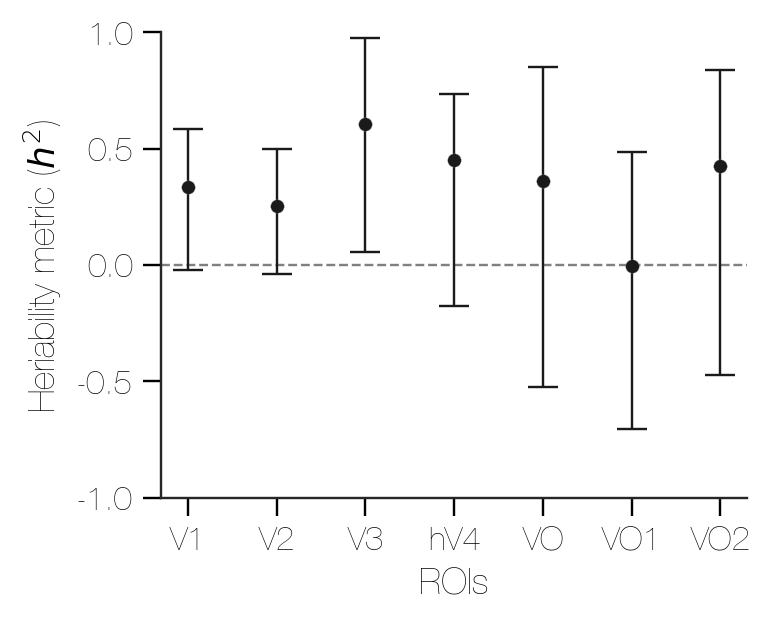

In [124]:
# 95% ci (it is important to see if the errorbar includes 0 )
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3.5,2.8))
hue_offsets = np.linspace(-0.2, 0.2, len(hues))  # Adjust based on the number of hues and desired spacing

rc = {'text.color': 'black',
      'axes.labelcolor': 'black',
      'axes.labelweight': 'light',
      'axes.linewidth':     0.8,
      'xtick.major.width':    0.8,
      'ytick.major.width':    0.8,
      'xtick.color': 'black',
      'ytick.color': 'black',
      'xtick.labelcolor': 'black',
      'ytick.labelcolor': 'black',
      'font.family': 'helveticaneue',
      'font.weight': 'light',
      'font.size' : 10,
      'figure.dpi': 72*3,
      'savefig.dpi': 72*4,
      }
mpl.rcParams.update(rc)
mpl.rcParams['axes.unicode_minus'] = False
sns.set_theme(context="notebook", style='ticks', rc=rc)

for i, category in enumerate(categories):
    # Filter data for this category and hue
    subset = final_icc_df[final_icc_df['ROI'] == category]
    x_positions = category_positions[i]
    # Add error bars (assuming 'CI95%' column contains [lower, upper] bounds)
    for _, row in subset.iterrows():
        ax.errorbar(x_positions, 
                    row['h2'], c='k', linewidth=0.8, elinewidth=0.8, markeredgewidth=0.8,
                    yerr=np.asarray([row['h2'] - row[f'h2_ci_95'][0],  row[f'h2_ci_68'][1]-row['h2']]).reshape(2,1), 
                    fmt='none', capsize=5, zorder=1)
    # Plot points
    ax.scatter([x_positions] * len(subset), 
               subset['h2'], s=20,   edgecolors='grey', linewidth=0.1,
               color = 'k', zorder=2)

ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_visible(True)
ax.axhline(y=0, linestyle='--', color='grey', linewidth=0.8, zorder=0)
ax.set(xticks=category_positions, xticklabels=categories, ylim=[-1, 1], yticks=[-1, -0.5, 0, 0.5, 1])
ax.set_xlabel('ROIs')
ax.set_ylabel(r'Heriability metric ($h^{2}$)')
plt.savefig(os.path.join(fig_dir, 'icc_2_hm_mono_dizy.svg'), bbox_inches='tight')
plt.savefig(os.path.join(fig_dir, 'icc_2_hm_mono_dizy.png'), bbox_inches='tight')

plt.show()

In [ ]:
bts_icc_std_df = bts_icc_df.groupby(['ROI','hemi']).std().reset_index()
bts_icc_std_df = bts_icc_std_df.rename(columns={'h2':'std_h2', 'mono_ICC':'std_mono_ICC', 'dizy_ICC':'std_dizy_ICC'})
final_icc_df = pd.merge(h2_df, bts_icc_std_df, on=['ROI','hemi'])